In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('/content/spam.csv', encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df = df[['v1', 'v2']]

In [6]:
df.columns = ['label', 'message']
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [7]:
df['label'] = df['label'].str.strip()
df['label'] = df['label'].map({'ham': 1, 'spam': 0})

In [8]:
df.head()

,label,message
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df['label'].value_counts()

,count
label,
1,4825
0,747


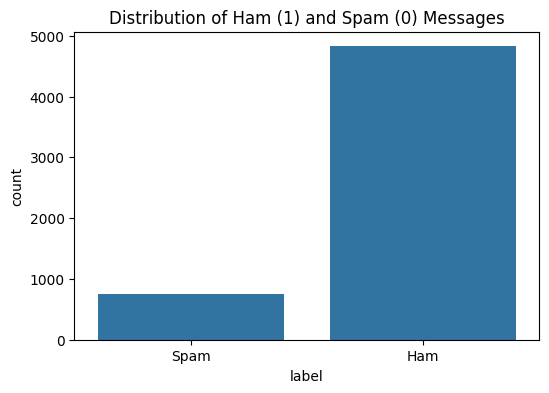

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham (1) and Spam (0) Messages')
plt.xticks([0, 1], ['Spam', 'Ham'])
plt.show()

In [11]:
df.isnull().sum()

,0
label,0
message,0


In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
def clean_text(clean_text):
    clean_text = clean_text.lower()
    clean_text = re.sub(r'https?://\S+|www\.\S+', '', clean_text)
    clean_text = re.sub(r'[^a-zA-Z\s]', '', clean_text)
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    return clean_text
df['clean_text'] = df['message'].astype(str).apply(clean_text)

In [16]:
df.head()

,label,message,clean_text
0,1,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,0,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,1,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,1,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [17]:
max_words = 50000
max_len = 200

X_text = df['clean_text'].values
y_labels = df['label'].values

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_text, y_labels, test_size=0.2, random_state=42)

In [19]:
tokenizer = Tokenizer(num_words=max_words, char_level=True, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

# Save tokenizer for later use
import joblib
joblib.dump(tokenizer, "tokenizer.pkl")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test  = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

In [20]:
print(f'Shape of training data: {X_train.shape}')
print(f'Shape of testing data: {X_test.shape}')

Shape of training data: (4135, 200)
Shape of testing data: (1034, 200)


In [21]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_len))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
dummy_input = np.zeros((1, max_len))
model(dummy_input)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 200, 64)           │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (1, 128)               │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,177 (1.47 MB)

 Trainable params: 386,177 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8715 - loss: 0.4123 - val_accuracy: 0.8924 - val_loss: 0.2980
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8776 - loss: 0.3077 - val_accuracy: 0.8948 - val_loss: 0.2618
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8915 - loss: 0.2592 - val_accuracy: 0.9045 - val_loss: 0.2198
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9084 - loss: 0.2314 - val_accuracy: 0.8984 - val_loss: 0.2298
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9069 - loss: 0.2304 - val_accuracy: 0.9190 - val_loss: 0.1979
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9069 - loss: 0.2357 - val_accuracy: 0.9129 - val_loss: 0.2179
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9199 - loss: 0.2240 - val_accuracy: 0.9262 - val_loss: 0.1913
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9229 - loss: 0.2020 - val_accuracy: 0.8875 - v

In [24]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9623 - loss: 0.1135

Test Accuracy: 96.23%


In [25]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [26]:
model.save("spamclassification.h5")

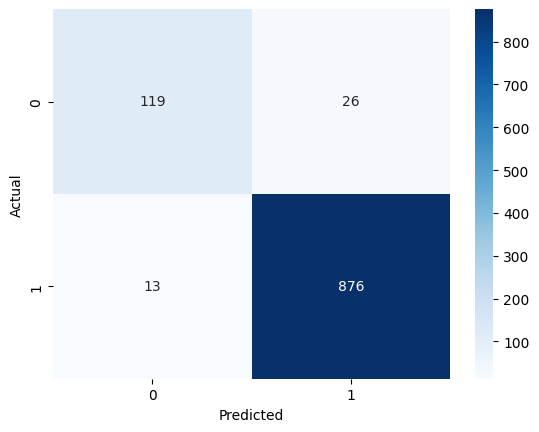

In [28]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86       145
           1       0.97      0.99      0.98       889

    accuracy                           0.96      1034
   macro avg       0.94      0.90      0.92      1034
weighted avg       0.96      0.96      0.96      1034



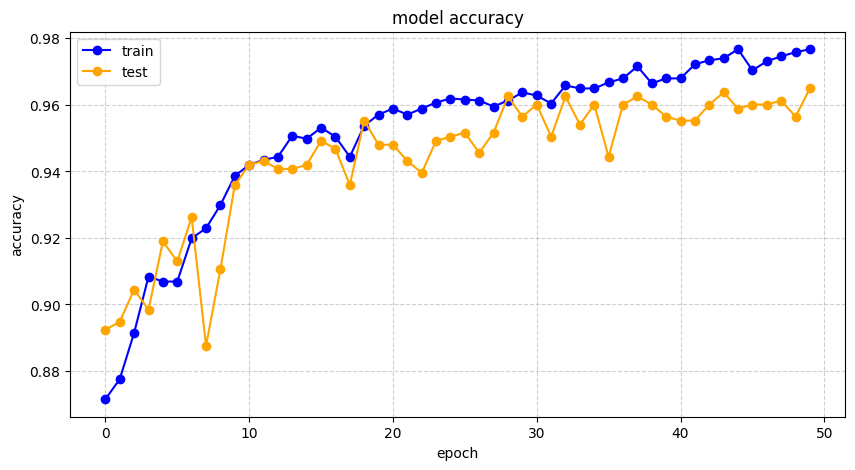

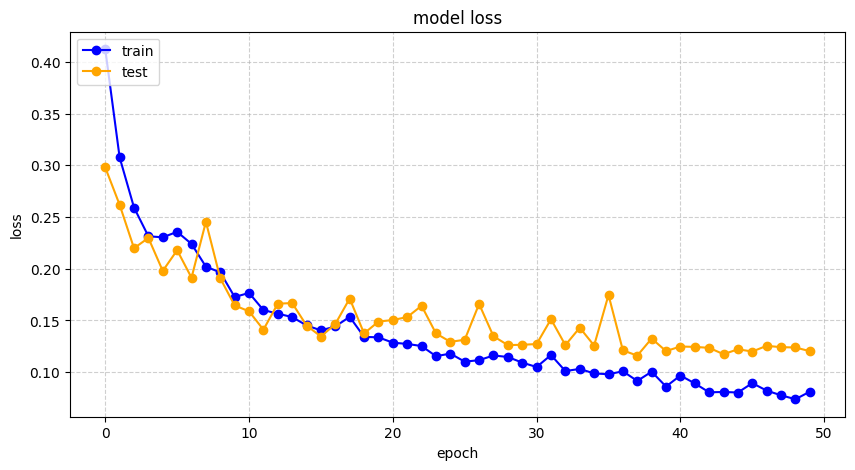

In [30]:
import matplotlib.pyplot as plt

# 1. رسم بياني للدقة (Model Accuracy)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='train', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='test', color='orange', marker='o')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. رسم بياني للخسارة (Model Loss)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='test', color='orange', marker='o')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()